In [2]:
import numpy as np
import matplotlib.pyplot as plt

2.3 3.3


Text(0.5, 0, 'frequency [GHz]')

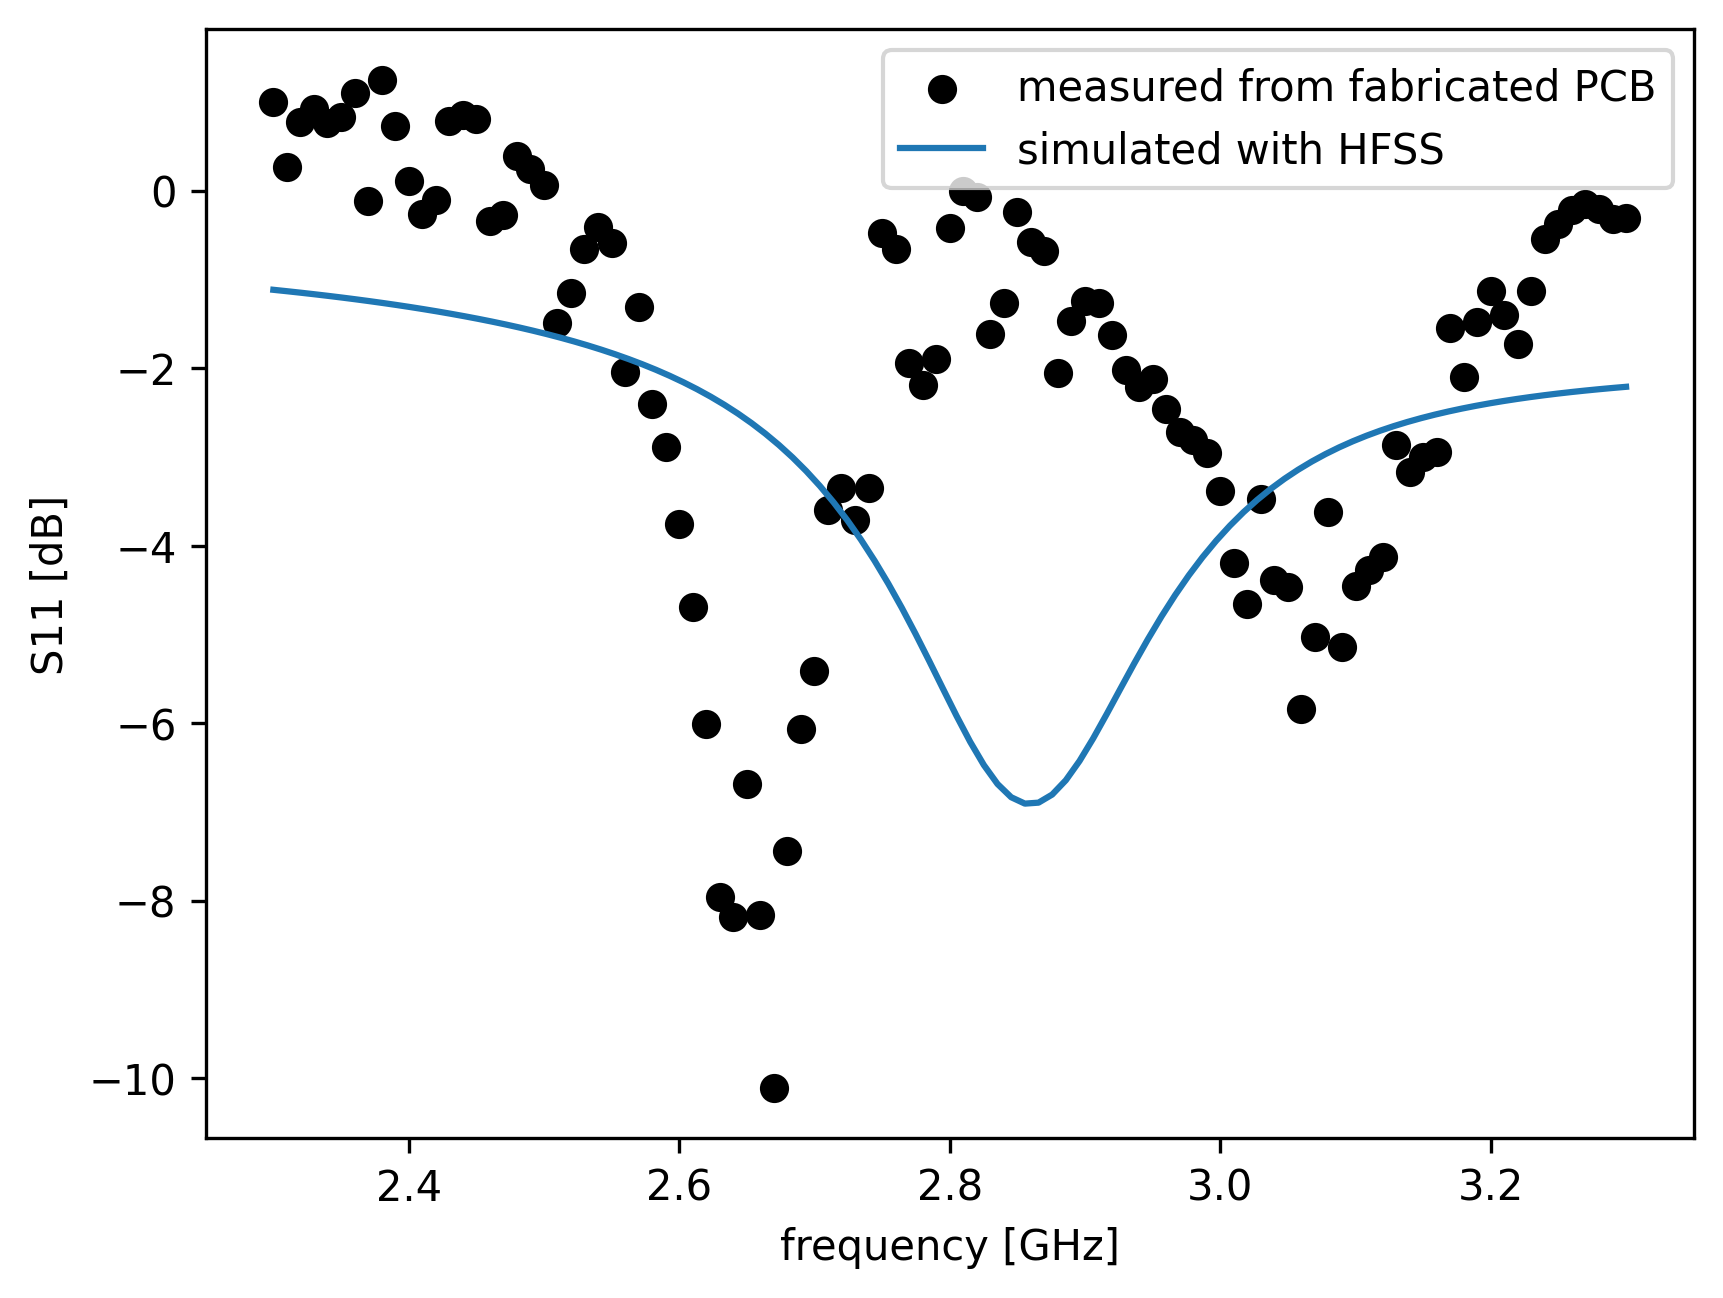

In [17]:
data = np.loadtxt("./pcb-4.s1p", comments=["#", "!"])

freq = data[:, 0] / 1e6  # MHz
re = data[:, 1]
im = data[:, 2]

s11_mag = np.sqrt(re**2 + im**2)
s11_db = 20 * np.log10(s11_mag)

dip_idx = np.argmin(s11_db)
fig, ax = plt.subplots(dpi=300)
ax.scatter(freq / 1000, s11_db, color="black", label="measured from fabricated PCB")

simulated_data = np.genfromtxt("../microwave/simulated-s11.csv", delimiter=",", skip_header=1)
freq = np.asarray(simulated_data[:, 3], dtype=np.float32)
s11 = np.asarray(simulated_data[:, 4], dtype=np.float32)
ax.plot(freq, s11, label="simulated with HFSS")
print(freq[0], freq[-1])
plt.legend()
ax.set_ylabel("S11 [dB]")
ax.set_xlabel("frequency [GHz]")


Text(0.5, 0, 'time [us]')

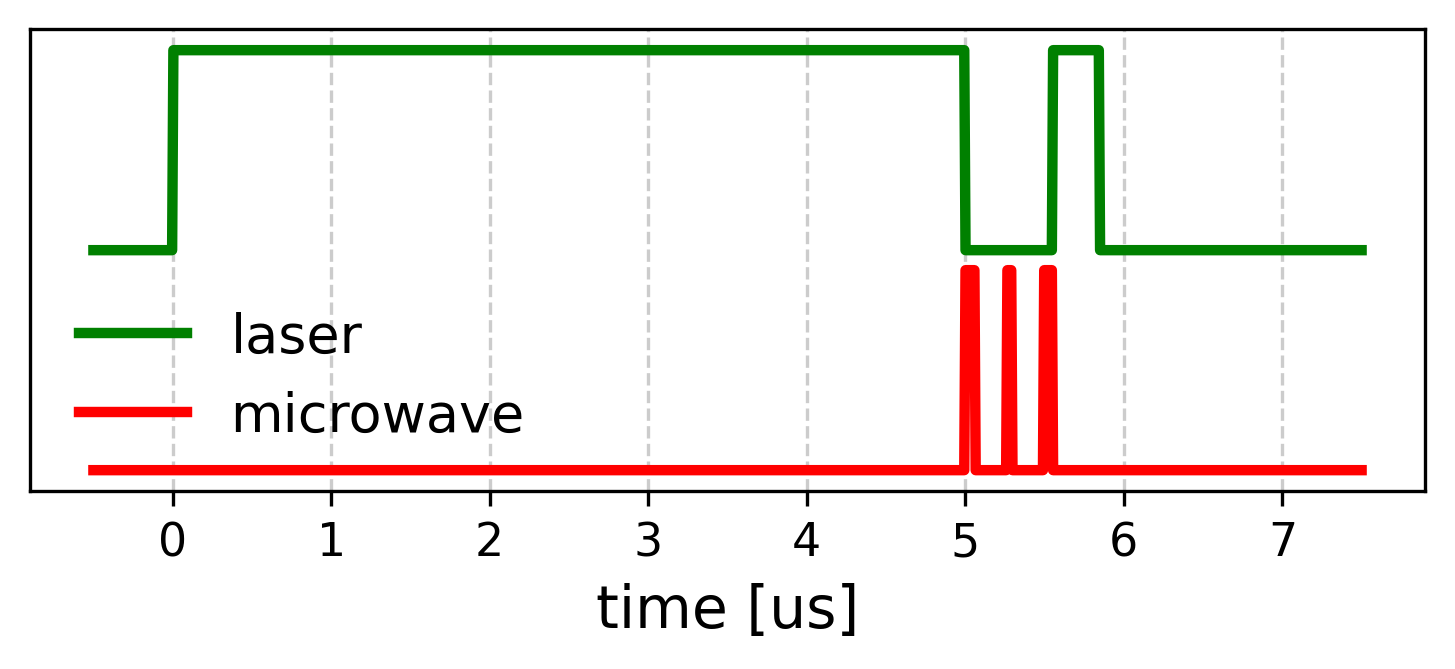

In [ ]:
plt.style.use("../plots.mplstyle")

EXCITATION = 5e-6
PI = 60e-9
PI_2 = PI / 2
READOUT = 300e-9
TAU = 200e-9
MICROWAVE = PI + TAU + PI_2 + TAU + PI
# SINGLE_CYCLE = AOM_DELAY + EXCITATION + MICROWAVE + AOM_DELAY + READOUT

edges = [0, \
         EXCITATION, \
         EXCITATION + MICROWAVE, \
         EXCITATION + MICROWAVE + READOUT, \
]
mw_edges = [EXCITATION, \
         EXCITATION + PI, \
         EXCITATION + PI + TAU, \
         EXCITATION + PI + TAU + PI_2, \
         EXCITATION + PI + TAU + PI_2 + TAU, \
         EXCITATION + PI + TAU + PI_2 + TAU + PI, \
        ]
readout_edges = [ 
    EXCITATION + MICROWAVE, \
         EXCITATION + MICROWAVE + READOUT, \
        ]
def generate_modulation(t, edges):
    y = np.zeros_like(t)
    for on, off in zip(edges[0::2], edges[1::2]):
        y[(t >= on) & (t < off)] = 1
    return t, y

t = np.linspace(-0.5e-6, 7.5e-6, 1000)
t, y = generate_modulation(t, edges)
t, y1 = generate_modulation(t, mw_edges)
t, y2 = generate_modulation(t, readout_edges)


fig, ax = plt.subplots(dpi=300, figsize=(6, 2))
ax.plot(t / 1e-6, y, label="laser", color="green")
ax.plot(t / 1e-6, y1 - 1.1, label="microwave", color="red")
ax.plot(t / 1e-6, y2 - 2.1, label="readout", color="red")

ax.yaxis.set_visible(False)

ax.set_yticks([])
plt.legend()
ax.set_xlabel("time [us]")


Text(0.5, 0, 'time [us]')

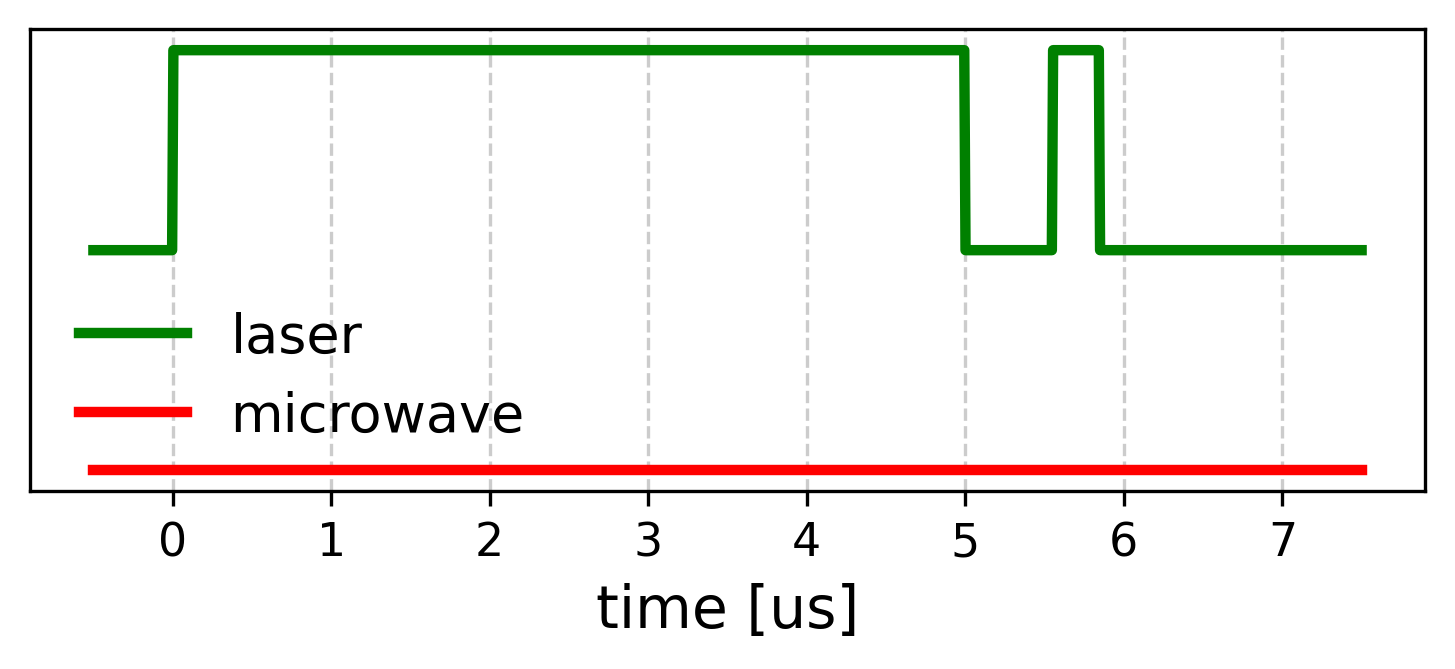

In [54]:
fig, ax = plt.subplots(dpi=300, figsize=(6, 2))
ax.plot(t / 1e-6, y, label="laser", color="green")
ax.plot(t / 1e-6, np.zeros_like(t) - 1.1, label="microwave", color="red")
ax.yaxis.set_visible(False)

ax.set_yticks([])
plt.legend()
ax.set_xlabel("time [us]")


Text(0.5, 0, 'time [s]')

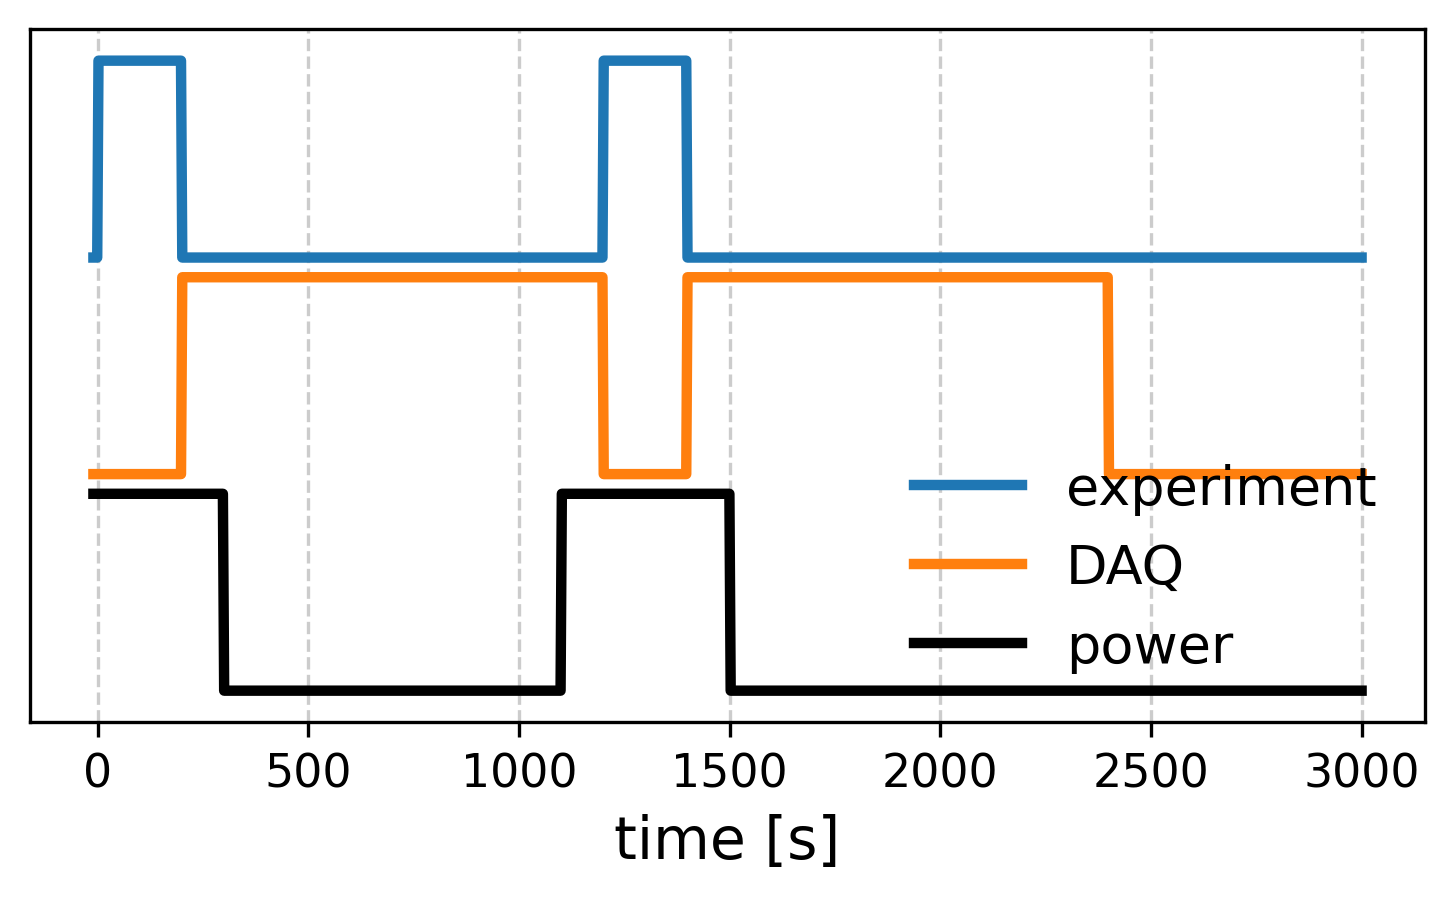

In [80]:

EXPERIMENT = 5e-6
PI = 60e-9
PI_2 = PI / 2
READOUT = 300e-9
TAU = 200e-9
MICROWAVE = PI + TAU + PI_2 + TAU + PI
SINGLE_CYCLE = 40e-3
SINGLE_DAQ = 0.2

exp_edges = [0, SINGLE_CYCLE * 5000, SINGLE_CYCLE * 5000 + SINGLE_DAQ * 5000, SINGLE_CYCLE * 5000 * 2 + SINGLE_DAQ * 5000 ]

daq_edges = [SINGLE_CYCLE * 5000, SINGLE_CYCLE * 5000 + SINGLE_DAQ * 5000, SINGLE_CYCLE * 5000 * 2 + SINGLE_DAQ * 5000, SINGLE_CYCLE * 5000 * 2 + SINGLE_DAQ * 5000 * 2]
power_edges =  [-10, SINGLE_CYCLE * 5000 + 100, SINGLE_CYCLE * 5000 + SINGLE_DAQ * 5000 - 100, SINGLE_CYCLE * 5000 * 2 + SINGLE_DAQ * 5000 + 100]

t = np.linspace(-10, 3000, 1000)
t, y = generate_modulation(t, exp_edges)
t, y1 = generate_modulation(t, daq_edges)
t, y2 = generate_modulation(t, power_edges)


fig, ax = plt.subplots(dpi=300, figsize=(6, 3))
ax.plot(t, y, label="experiment")
ax.plot(t, y1 - 1.1, label="DAQ")
ax.plot(t, y2 - 2.2, label="power", color="black")

ax.yaxis.set_visible(False)

ax.set_yticks([])
plt.legend(loc="lower right")
ax.set_xlabel("time [s]")
